In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
os.chdir('drive/MyDrive/Bee')
print(os.listdir())

['README.md', 'LICENSE', 'requirements.txt', 'Test.ipynb', 'scripts', 'src', 'notebooks', 'data']


In [3]:
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

from src.dataset import BeeSegmentationDataset
from src.models.base import UNet3

In [4]:
dataset = BeeSegmentationDataset("data/images", "data/masks")

# Split: train/test -> train + test
train_len = int(0.8 * len(dataset))
test_len = len(dataset) - train_len
train_val_dataset, test_dataset = random_split(dataset, [train_len, test_len], generator=torch.Generator().manual_seed(42))

# Now split train_val into train/val (80/20)
val_len = int(0.2 * len(train_val_dataset))
train_len = len(train_val_dataset) - val_len
train_dataset, val_dataset = random_split(train_val_dataset, [train_len, val_len], generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 640, Val: 160, Test: 201


In [5]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16)
test_loader = DataLoader(test_dataset, batch_size=16)

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = UNet3().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
weights = torch.tensor([0.1, 1.0, 1.0]).to(device)  # Tune as needed
criterion = nn.CrossEntropyLoss(weight=weights)

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    epoch_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    return epoch_loss / len(loader)

In [8]:
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    val_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        loss = criterion(outputs, masks)
        val_loss += loss.item()
    return val_loss / len(loader)


In [9]:
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{num_epochs}  Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

Epoch 1/100  Train Loss: 0.7576  Val Loss: 1.3654
Epoch 2/100  Train Loss: 0.5937  Val Loss: 0.6237
Epoch 3/100  Train Loss: 0.5271  Val Loss: 0.6339
Epoch 4/100  Train Loss: 0.4903  Val Loss: 0.5731
Epoch 5/100  Train Loss: 0.4589  Val Loss: 0.5240
Epoch 6/100  Train Loss: 0.4353  Val Loss: 0.5598
Epoch 7/100  Train Loss: 0.4249  Val Loss: 0.5067
Epoch 8/100  Train Loss: 0.4048  Val Loss: 0.5074
Epoch 9/100  Train Loss: 0.4044  Val Loss: 0.5130
Epoch 10/100  Train Loss: 0.3892  Val Loss: 0.4804
Epoch 11/100  Train Loss: 0.3753  Val Loss: 0.4784
Epoch 12/100  Train Loss: 0.3636  Val Loss: 0.6703
Epoch 13/100  Train Loss: 0.3588  Val Loss: 0.5309
Epoch 14/100  Train Loss: 0.3445  Val Loss: 0.5008
Epoch 15/100  Train Loss: 0.3369  Val Loss: 0.5824
Epoch 16/100  Train Loss: 0.3239  Val Loss: 0.5176
Epoch 17/100  Train Loss: 0.2967  Val Loss: 0.6358
Epoch 18/100  Train Loss: 0.2963  Val Loss: 0.5562
Epoch 19/100  Train Loss: 0.2837  Val Loss: 0.6381
Epoch 20/100  Train Loss: 0.2718  Val Lo

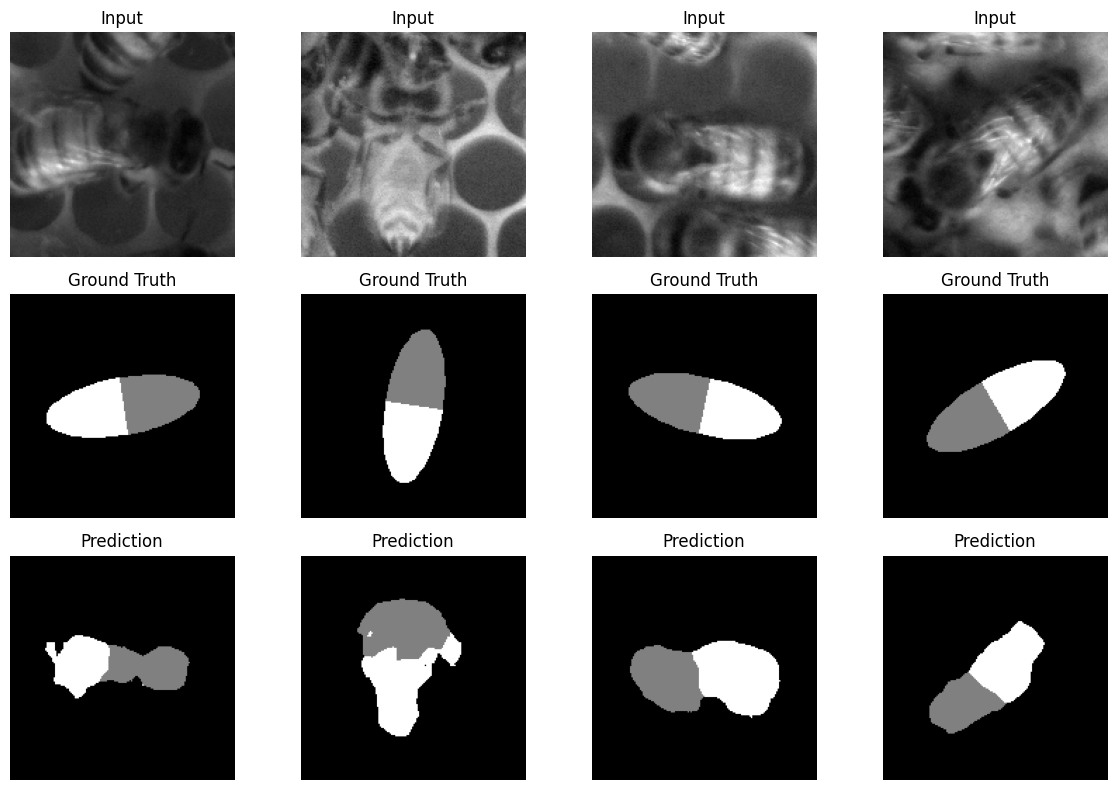

In [10]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(device)
outputs = model(images).argmax(dim=1).cpu()

fig, axs = plt.subplots(3, 4, figsize=(12, 8))
for i in range(4):
    axs[0, i].imshow(images[i][0].cpu(), cmap="gray")
    axs[0, i].set_title("Input")

    axs[1, i].imshow(masks[i].cpu(), cmap="gray")
    axs[1, i].set_title("Ground Truth")

    axs[2, i].imshow(outputs[i], cmap="gray")
    axs[2, i].set_title("Prediction")

for ax in axs.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
model.eval()
images, masks = next(iter(test_loader))
images = images.to(device)
outputs = model(images).argmax(dim=1).cpu()

fig, axs = plt.subplots(3, 4, figsize=(12, 8))
for i in range(4):
    axs[0, i].imshow(images[i][0].cpu(), cmap="gray")
    axs[0, i].set_title("Input")

    axs[1, i].imshow(masks[i].cpu(), cmap="gray")
    axs[1, i].set_title("Ground Truth")

    axs[2, i].imshow(outputs[i], cmap="gray")
    axs[2, i].set_title("Prediction")

for ax in axs.flat:
    ax.axis("off")

plt.tight_layout()
plt.show()


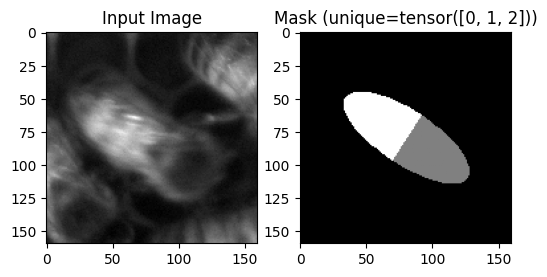

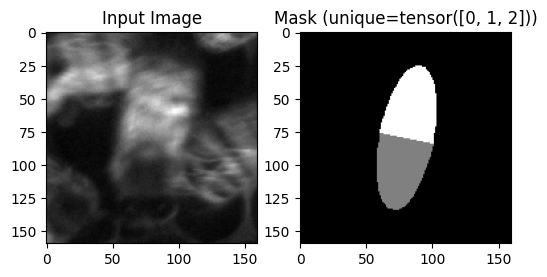

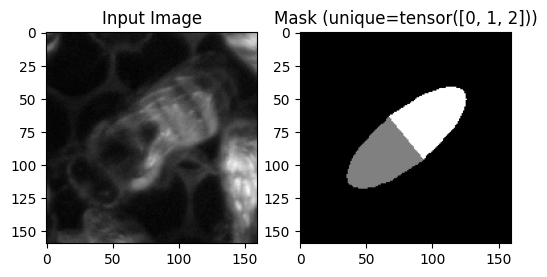

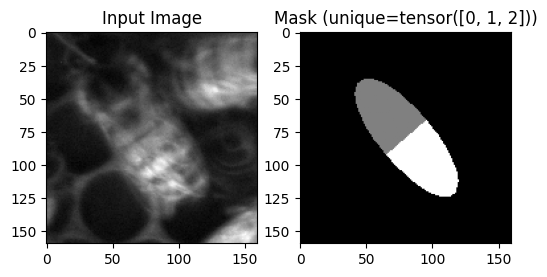

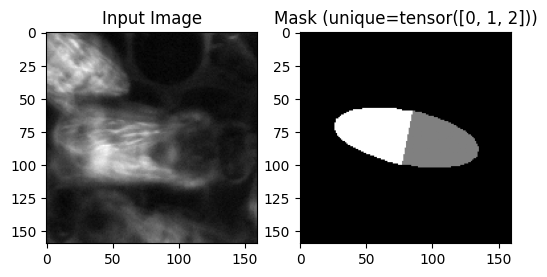

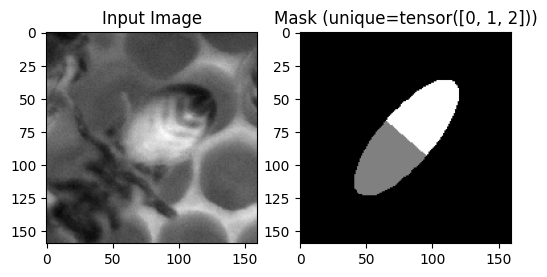

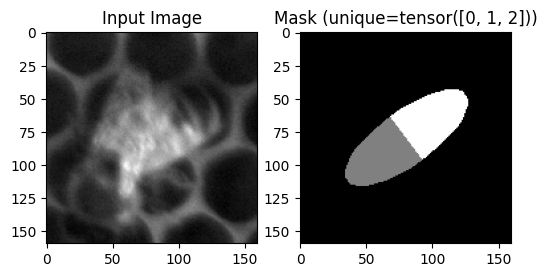

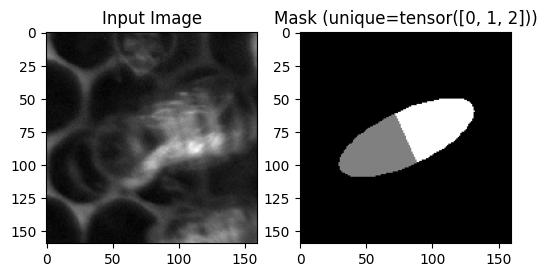

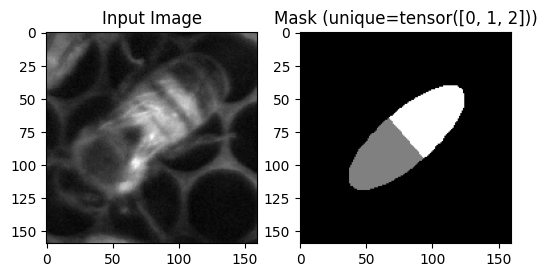

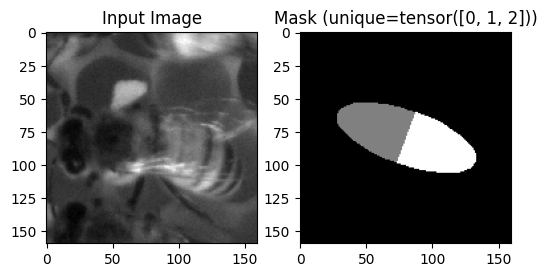

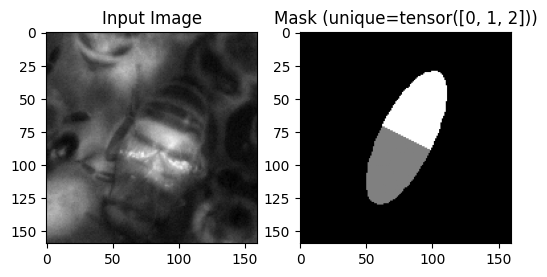

In [11]:
for i in range(11):
    image, mask = train_dataset[i]
    plt.figure(figsize=(6, 3))
    plt.subplot(1, 2, 1)
    plt.imshow(image[0], cmap='gray')
    plt.title("Input Image")
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask (unique={torch.unique(mask)})")
    plt.show()
